In [1]:
import random
import numpy as np
from matplotlib import pyplot as plt

### **Curve Fitting using Memetic Algorithm**

Memetic Algorithm is Genetic Algorithm plus *`Local Search`* !

The *`Local Search`* is applied for top 3 children in each iteration. It randomly changes some genes to reaches a better answer!

In [2]:
class Chromosome:
    def __init__(self, n:int, s:int, e:int) -> None:
        self.s = s
        self.e = e
        self.n = n
        self.coefficient = list(random.uniform(s, e) for _ in range(n+1))
        self.fitness = s
        self.calc_fitness()
    
    def mutation(self, alpha =.99) -> None:
        if random.random() < alpha:
            a = random.randint(0,self.n)
            b = random.randint(0,self.n)
                     
            self.coefficient[a] = self.e - self.coefficient[a]
            self.coefficient[b] = self.e - self.coefficient[b]
            if self.coefficient[a] > self.e:
                self.coefficient[a] -= self.e
            if self.coefficient[a] < self.s:
                self.coefficient[a] += self.s    

            if self.coefficient[b] > self.e:
                self.coefficient[b] -= self.e
            if self.coefficient[b] < self.s:
                self.coefficient[b] += self.s    
                
        self.calc_fitness()
    
    def calc_fitness(self) -> int:
        error = 0
        for i in range(points_num):
            x = points[i]
            res = 0
            for j in range(self.n+1):
                res += self.coefficient[j] * (x[0]**j)
            if res != 0:
                error += abs((x[1] - res) / res)*100
            
        error /= points_num
        self.fitness = error

    def localSearch(self, iteration= 20):
        for _ in range(iteration):
            temp = Chromosome(self.n, self.s, self.e)
            temp.coefficient = self.coefficient.copy()
            for _ in range(self.n//20):
                a = random.randint(0,self.n)
                b = random.randint(0,self.n)
                temp.coefficient[a] *= ((100+temp.fitness)/100)
                temp.coefficient[b] *= ((100-temp.fitness)/100)
            temp.calc_fitness()
            if temp.fitness < self.fitness:
                self.fitness = temp.fitness
                self.coefficient = temp.coefficient
        
    def plot(self):
        x = np.linspace(-20, 20, 100)
        y = 0    
        for j in range(self.n+1):
            y += self.coefficient[j] * (x**j)

        plt.plot(x, y, label='Curve')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Curve')
        plt.grid(True)
        plt.legend()
        plt.show()

In [3]:
def cross_over(par1 : Chromosome, par2:Chromosome, alpha:int = 0.5) -> Chromosome:
    child = Chromosome(par1.n, par1.s, par1.e)
    
    for i in range(par1.n//3):
        child.coefficient[i] = par1.coefficient[i]

    for i in range(par1.n//3, par1.n):
        child.coefficient[i] = alpha * (par1.coefficient[i] + par2.coefficient[i])
            
    child.calc_fitness()
    return child

In [4]:
def MA(pop_size, n, s, e) -> Chromosome:
    population = [Chromosome(n, s, e) for _ in range(pop_size)]

    count = 0
    perv = 0
    population.sort(key = lambda x :x.fitness)
    
    while (True):
        children = []        
        sample = population[:int(pop_size*.55)]
        for _ in range(pop_size):
            parents = random.choices(sample, k = 2)
            child = cross_over(*parents)
            child.mutation()
            children.append(child)
            
            child2 = (cross_over(parents[1], parents[0]))
            child2.mutation()
            children.append(child2)
            
            
        children.sort(key = lambda x :x.fitness)
        for i in range(3):
            children[i].localSearch()

        population = population[ :pop_size-1] + children[ :1] 
        """ trade-off between exploration & exploitation """
        population.sort(key = lambda x :x.fitness)

        print('best fitness: %' , round(population[0].fitness, 3), "\t \t worse fitness: %" , round(population[-1].fitness, 3) ,sep='')
        
        if (population[0].fitness == perv):
            count +=1
        else:
            count = 0
            perv = population[0].fitness
        
        if (count > 100):
            break
        
    return population[0]      

In [5]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test1.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

In [6]:
res = MA(200, n, s, e)

best fitness: %31.167	 	 worse fitness: %1482.897
best fitness: %31.167	 	 worse fitness: %1351.051
best fitness: %31.167	 	 worse fitness: %653.476
best fitness: %31.167	 	 worse fitness: %541.226
best fitness: %31.167	 	 worse fitness: %528.684
best fitness: %31.167	 	 worse fitness: %506.823
best fitness: %31.167	 	 worse fitness: %454.376
best fitness: %31.167	 	 worse fitness: %411.403
best fitness: %9.733	 	 worse fitness: %331.022
best fitness: %9.733	 	 worse fitness: %310.38
best fitness: %9.733	 	 worse fitness: %267.146
best fitness: %9.733	 	 worse fitness: %265.515
best fitness: %9.733	 	 worse fitness: %264.449
best fitness: %9.733	 	 worse fitness: %257.714
best fitness: %9.733	 	 worse fitness: %257.394
best fitness: %9.733	 	 worse fitness: %257.101
best fitness: %9.733	 	 worse fitness: %242.335
best fitness: %9.733	 	 worse fitness: %225.334
best fitness: %9.733	 	 worse fitness: %222.547
best fitness: %9.733	 	 worse fitness: %219.795
best fitness: %9.733	 	 worse f

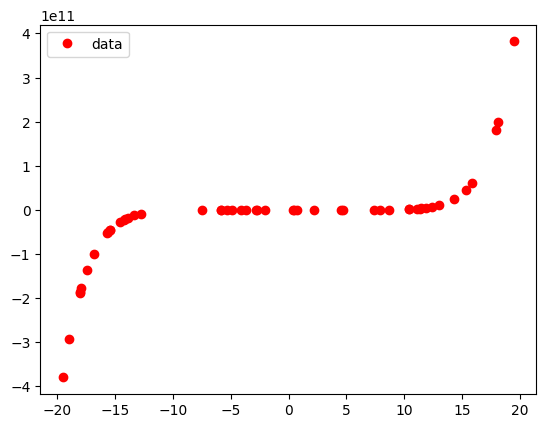

In [7]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

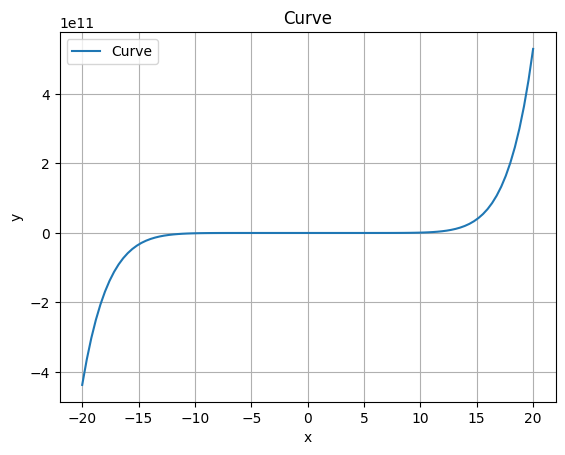

In [8]:
res.plot()

In [9]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test2.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

res = MA(200, n, s, e)

best fitness: %41.595	 	 worse fitness: %2628.836
best fitness: %18.447	 	 worse fitness: %1878.998
best fitness: %18.447	 	 worse fitness: %1649.373
best fitness: %18.447	 	 worse fitness: %1304.187
best fitness: %18.447	 	 worse fitness: %1180.943
best fitness: %18.447	 	 worse fitness: %1140.257
best fitness: %18.447	 	 worse fitness: %1136.824
best fitness: %18.447	 	 worse fitness: %1016.729
best fitness: %18.447	 	 worse fitness: %921.621
best fitness: %18.447	 	 worse fitness: %909.411
best fitness: %18.447	 	 worse fitness: %815.558
best fitness: %18.447	 	 worse fitness: %765.26
best fitness: %18.447	 	 worse fitness: %749.826
best fitness: %18.447	 	 worse fitness: %738.739
best fitness: %18.447	 	 worse fitness: %723.349
best fitness: %18.016	 	 worse fitness: %709.689
best fitness: %18.016	 	 worse fitness: %702.063
best fitness: %16.543	 	 worse fitness: %697.869
best fitness: %16.543	 	 worse fitness: %662.32
best fitness: %16.543	 	 worse fitness: %643.229
best fitness: 

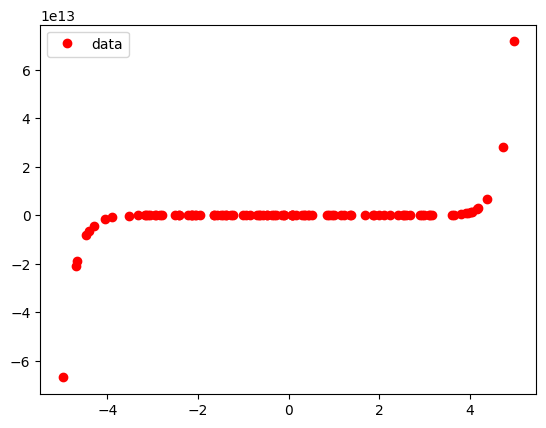

In [10]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

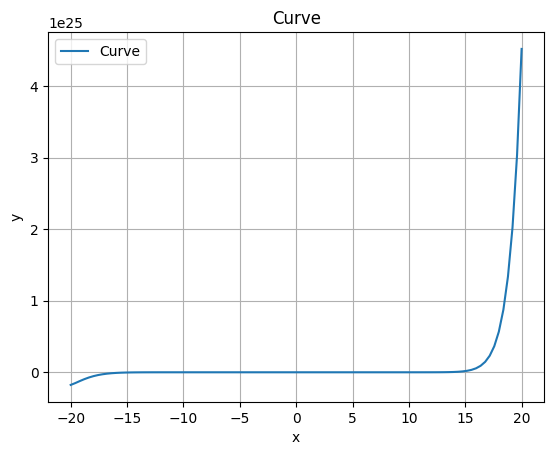

In [11]:
res.plot()

In [12]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test3.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

res = MA(200, n, s, e)

best fitness: %57.946	 	 worse fitness: %26872.095
best fitness: %37.388	 	 worse fitness: %2839.64
best fitness: %37.388	 	 worse fitness: %2728.149
best fitness: %37.388	 	 worse fitness: %1492.442
best fitness: %37.388	 	 worse fitness: %1245.783
best fitness: %37.388	 	 worse fitness: %1233.939
best fitness: %37.388	 	 worse fitness: %967.505
best fitness: %37.388	 	 worse fitness: %917.001
best fitness: %37.388	 	 worse fitness: %829.218
best fitness: %37.388	 	 worse fitness: %818.436
best fitness: %36.234	 	 worse fitness: %787.976
best fitness: %36.234	 	 worse fitness: %773.783
best fitness: %32.407	 	 worse fitness: %771.134
best fitness: %32.407	 	 worse fitness: %682.449
best fitness: %32.407	 	 worse fitness: %647.213
best fitness: %32.407	 	 worse fitness: %641.967
best fitness: %32.407	 	 worse fitness: %593.82
best fitness: %32.407	 	 worse fitness: %591.78
best fitness: %32.407	 	 worse fitness: %577.611
best fitness: %30.635	 	 worse fitness: %577.129
best fitness: %3

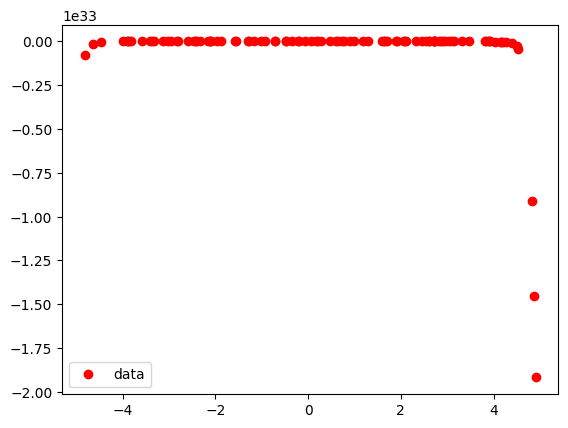

In [13]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

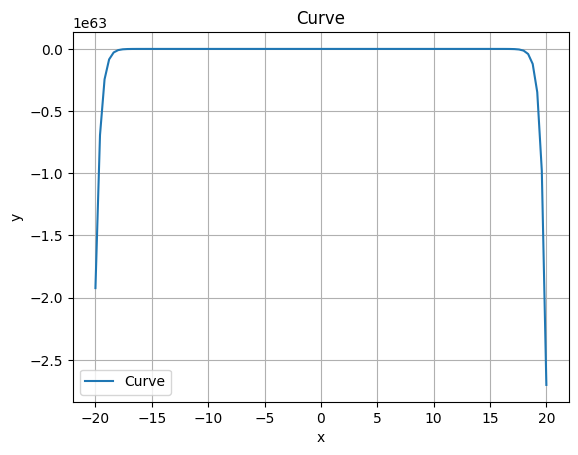

In [14]:
res.plot()

In [15]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test4.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

res = MA(200, n, s, e)

best fitness: %39.398	 	 worse fitness: %1391.724
best fitness: %39.398	 	 worse fitness: %1311.461
best fitness: %39.398	 	 worse fitness: %1044.778
best fitness: %25.331	 	 worse fitness: %1012.421
best fitness: %25.331	 	 worse fitness: %905.649
best fitness: %25.331	 	 worse fitness: %778.879
best fitness: %25.331	 	 worse fitness: %738.462
best fitness: %25.331	 	 worse fitness: %646.146
best fitness: %25.331	 	 worse fitness: %636.801
best fitness: %25.331	 	 worse fitness: %609.652
best fitness: %25.331	 	 worse fitness: %547.098
best fitness: %25.331	 	 worse fitness: %517.738
best fitness: %25.331	 	 worse fitness: %513.926
best fitness: %25.331	 	 worse fitness: %492.037
best fitness: %15.572	 	 worse fitness: %486.899
best fitness: %15.572	 	 worse fitness: %452.751
best fitness: %15.572	 	 worse fitness: %446.294
best fitness: %15.572	 	 worse fitness: %416.291
best fitness: %15.572	 	 worse fitness: %415.87
best fitness: %15.572	 	 worse fitness: %396.308
best fitness: %15

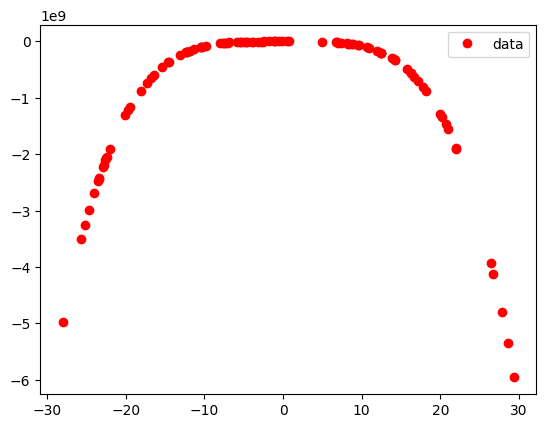

In [16]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

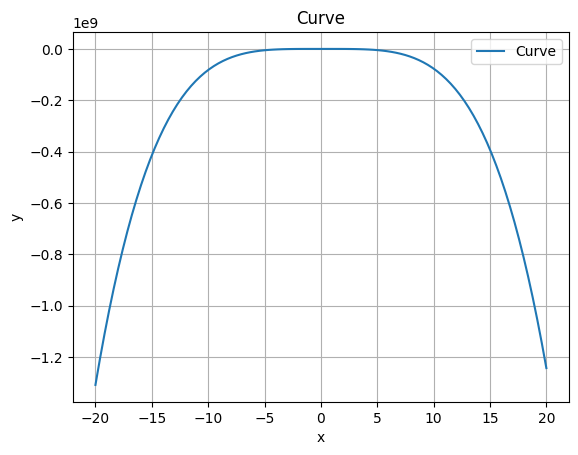

In [17]:
res.plot()
